In [34]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error as mae
import scipy.stats as ss

#we also want to import column transformer to transform categorical variables and we want to import pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

## Load the datasets

In [6]:
X_train = pd.read_csv('./X_train.csv')
y_train = pd.read_csv('./y_train.csv')

X_test = pd.read_csv('./X_test.csv')
y_test = pd.read_csv('./y_test.csv')

X_val = pd.read_csv('./X_val.csv')
y_val = pd.read_csv('./y_val.csv')

## 1) Part 1: XGB model

### set up regression xgb model
In stage 1, find the best parameters

In stage 2, run best parameters with early stopping. Now include validation sample as well

In [31]:
#define the model
#stage 1:
xgbmodel = xgb.XGBRegressor(objective='reg:squarederror', random_state = 42, n_estimators = 500)
params = {'learning_rate': [1e-3, 2e-2, 5e-2, 1e-2, 1e-1],
          'max_depth' : ss.randint(1, 10), #randint gets random numbers from a to N-1
          'min_child_weight': ss.uniform(5, 200), #scipy stats uniform takes a, b-a
          'colsample_bytree': ss.uniform(.4, .6)}

search = RandomizedSearchCV(estimator = xgbmodel,
                            param_distributions = params,
                            n_iter = 30,
                            cv = 3,
                            verbose = 0,
                            scoring = 'neg_mean_absolute_error',
                            n_jobs = -1)
search.fit(X_train, y_train)
print(f'Best params obtained: {search.best_params_}')

#stage 2:
best_xgb_model = xgb.XGBRegressor(**search.best_params_, n_estimators = 500, early_stopping_rounds = 20, eval_metric = 'mae')
best_xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=True)

Best params obtained: {'colsample_bytree': 0.8202347188745774, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 105.70453873636045}
[0]	validation_0-mae:0.01654
[1]	validation_0-mae:0.01591
[2]	validation_0-mae:0.01526
[3]	validation_0-mae:0.01466
[4]	validation_0-mae:0.01411
[5]	validation_0-mae:0.01359
[6]	validation_0-mae:0.01309
[7]	validation_0-mae:0.01262
[8]	validation_0-mae:0.01220
[9]	validation_0-mae:0.01180
[10]	validation_0-mae:0.01143
[11]	validation_0-mae:0.01106
[12]	validation_0-mae:0.01074
[13]	validation_0-mae:0.01060
[14]	validation_0-mae:0.01026
[15]	validation_0-mae:0.00999
[16]	validation_0-mae:0.00990
[17]	validation_0-mae:0.00963
[18]	validation_0-mae:0.00940
[19]	validation_0-mae:0.00917
[20]	validation_0-mae:0.00897
[21]	validation_0-mae:0.00879
[22]	validation_0-mae:0.00861
[23]	validation_0-mae:0.00846
[24]	validation_0-mae:0.00828
[25]	validation_0-mae:0.00813
[26]	validation_0-mae:0.00802
[27]	validation_0-mae:0.00789
[28]	validation_0-mae:0.0077

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8202347188745774, device=None,
             early_stopping_rounds=20, enable_categorical=False,
             eval_metric='mae', feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=105.70453873636045, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

### now, check performance on training and validation (which is out of time)

In [42]:
yhat_xgb_train = best_xgb_model.predict(X_train)
yhat_xgb_val = best_xgb_model.predict(X_val)

print(f'Train MAE = {mae(y_train, yhat_xgb_train)}')
print(f'Val MAE = {mae(y_val, yhat_xgb_val)}')
print(f'Train r-squared = {r2_score(y_train, yhat_xgb_train)}')
print(f'Val r-squared = {r2_score(y_val, yhat_xgb_val)}')

Train MAE = 0.005050304480357657
Val MAE = 0.005718612980168411
Train r-squared = 0.8948865271090884
Val r-squared = 0.8614905579817476


### Finally, what is performance on test data?

In [43]:
yhat_xgb_test = best_xgb_model.predict(X_test)
print(f'Test MAE = {mae(y_test, yhat_xgb_test)}_xgb')
print(f'Test r-squared = {r2_score(y_test, yhat_xgb_test)}')

Test MAE = 0.009095895067552574_xgb
Test r-squared = 0.7387615243692809


## 2. Let's try a simple linear regression and see what we get

In [46]:
'''
#handle categorical vars
cat_vars = [col for col in X_train.columns if X_train[col].nunique() < 10] #likely to have low cardinality

#ColumnTransform takes two inputs. The list of tuples ('name', tool to use, [columns]), and default treatment
preprocessor = ColumnTransformer(transformers = [('cat', OneHotEncoder(), cat_vars)], remainder = "passthrough")

#chain this preprocessor with the regressor object within a pipeline
model = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])
'''

#actually, the above is not necessary because all categorical variables are binary!
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

### predict using linear regression model

In [49]:
yhat_lr_train = linear_model.predict(X_train)
yhat_lr_val = linear_model.predict(X_val)
yhat_lr_test = linear_model.predict(X_test)

print(f'Train MAE = {mae(y_train, yhat_lr_train)}')
print(f'Val MAE = {mae(y_val, yhat_lr_val)}')
print(f'Train r-squared = {r2_score(y_train, yhat_lr_train)}')
print(f'Val r-squared = {r2_score(y_val, yhat_lr_val)}')

#test data
print(f'Test MAE = {mae(y_test, yhat_lr_test)}')
print(f'Test r-squared = {r2_score(y_test, yhat_lr_test)}')

Train MAE = 0.0075328652293764125
Val MAE = 0.007651835041247974
Train r-squared = 0.8020402783184717
Val r-squared = 0.7804348423322339
Test MAE = 0.010515143984162615
Test r-squared = 0.6811423444382534


### We could try lasso to reduce the effect of multicollinearity, but seeing how XGB gives good results, we'll stick with it and now we need to see what's up with the 73% $R^2$

## 3. Can we improve test results?

### 3.1 RCA by plotting residuals as a function of time

In [64]:
df_test = pd.read_csv('./rmbs_test.csv')
df_test['cpr_pred'] = best_xgb_model.predict(X_test)
df_test.head()

,loan_id,vintage_month,observation_month,original_rate,current_rate,refi_incentive,refi_incentive_pos,refi_incentive_sq,cumulative_incentive,burnout_proxy,...,loan_balance,loan_type_arm,investment_property,underwater,high_ltv,prime_borrower,jumbo,smm,cpr,cpr_pred
0,L095_00000,95,121,4.383007,4.628571,-0.245564,0.000000,0.060302,1.253229,0.686624,...,258862.345256,0,0,0,0,1,0,0.005666,0.065913,0.060973
1,L095_00001,95,121,4.695999,4.628571,0.067428,0.067428,0.004547,7.820556,0.200000,...,143555.849660,0,0,0,1,1,0,0.003959,0.046490,0.054383
2,L095_00002,95,121,4.525236,4.628571,-0.103336,0.000000,0.010678,3.573288,0.342328,...,316847.195673,1,0,0,1,1,0,0.003091,0.036471,0.057267
3,L095_00003,95,121,4.344981,4.628571,-0.283590,0.000000,0.080423,0.832668,0.778956,...,511471.826287,0,0,0,1,1,0,0.007188,0.082926,0.081856
4,L095_00004,95,121,4.535240,4.628571,-0.093331,0.000000,0.008711,3.782897,0.321464,...,605010.989839,0,0,0,1,0,0,0.003115,0.036749,0.045286


(22,) (24600, 29)


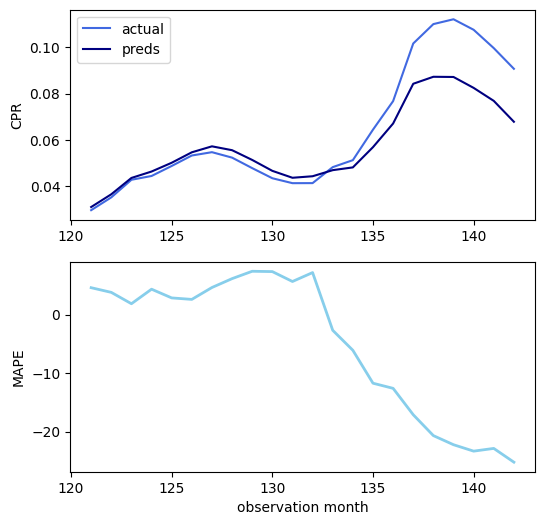

In [92]:
print(df_test.observation_month.value_counts().index.shape, df_test.shape)
df_grouped = df_test.groupby('observation_month').agg(mean_actual_cpr = ('cpr', 'mean'),
                                                      mean_pred_cpr = ('cpr_pred', 'mean')).reset_index()
df_grouped['MAPE'] = (df_grouped.mean_pred_cpr - df_grouped.mean_actual_cpr)/(df_grouped.mean_actual_cpr) * 100.
    
fig, axs = plt.subplots(2,1, figsize = (6, 6))
axs[0].plot(df_grouped.observation_month, df_grouped.mean_actual_cpr, label='actual', color = 'royalblue')
axs[0].plot(df_grouped.observation_month, df_grouped.mean_pred_cpr, label='preds', color = 'navy')
axs[0].set_ylabel('CPR')
axs[0].legend()

axs[1].plot(df_grouped.observation_month, df_grouped.MAPE, color = 'skyblue', linewidth = 2)
axs[1].set_ylabel('MAPE')
axs[1].set_xlabel('observation month');

### Clearly past month 132 or so gap increases. But also notice how this error is systematic, i.e. we underpredict!

### 3.2 Now that we observed greater error past the 132-ish month mark, we need to identify whether this corresponds to a regime change. Select a few regime vars and look at them

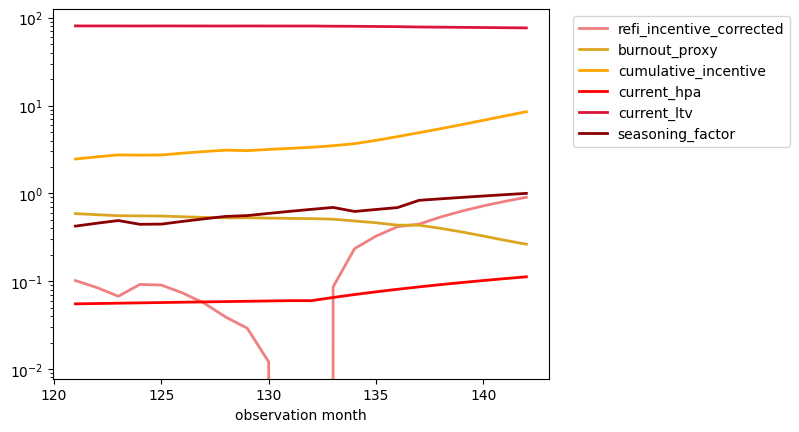

In [114]:
regime_features = [ 'refi_incentive', 'burnout_proxy', 'cumulative_incentive', 'current_hpa', 'current_ltv', 'seasoning_factor']
df_regime = df_test.groupby('observation_month')[regime_features].mean().reset_index()
epsilon = 1e-6
df_regime['refi_incentive_corrected'] = df_regime.refi_incentive.apply(lambda x: x+epsilon) #stability for log plot
plot_features = [ 'refi_incentive_corrected', 'burnout_proxy', 'cumulative_incentive', 'current_hpa', 'current_ltv', 'seasoning_factor']

#do a log plot so they can all be in one
fig, ax = plt.subplots()
colors = ['lightcoral', 'goldenrod', 'orange', 'red', 'crimson', 'darkred']
for i, var in enumerate(plot_features):
    ax.semilogy(df_regime.observation_month, df_regime[var], label=var, color=colors[i], linewidth = 2)
ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.0))
ax.set_xlabel('observation month');

### As expected, a regime change does appear to happen around month 132 or so. Notice how:
- cumulative incentive goes up. But notice how it was moving slowly and then accelerated! 
- incentive goes up
- burnout goes down. It depends on cum incentive anyway, but this means the pool has tons of borrowers who can still re-finance
- hpa goes up
- ltv goes down. A sign of low risk for borrowers, which accompanies low interest rates
- seasoning factor goes up (expected with time, anyway)
### Everything points toward a sudden event that would cause mass refinancing. Perhaps interest rates dropped sharply. Model drop in predictive power was to be expected because of sudden regime change!

## 4. To conclude we will save the test scores and take it back up with the HMM + post-hoc adjustments

In [118]:
df_scores = pd.read_csv('./rmbs_test.csv').copy()
df_scores['cpr_pred'] = yhat_xgb_test
df_scores.to_csv('./scores/df_test_with_scores.csv', index=False)